In [2]:
from datascience import *
from prob140 import *
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
%matplotlib inline

### Data 188, Spring 2024 ###
# Week 1 Seminar Notes #
### A. Adhikari ###

## Warm-Up: Confidence Intervals ##

We start with a review of Data 140 content. Let $X_1, X_2, \ldots, X_n$ be i.i.d. with mean $\mu$ and variance $\sigma^2$. Let $\bar{X}_n = \frac{1}{n}\sum_{i=1}^n X_i$ be the sample mean.

Then $E(\bar{X}_n) = \mu$ and $SD(\bar{X}_n) = \sigma/\sqrt{n}$ for all $n$. If $n$ is large, then the distribution of $\bar{X_n}$ is approximately normal by the CLT. This allows us to construct confidence intervals for the population mean.

Today we'll stick to 95% as the confidence level. To change levels and to read textbooks, it's worth going over some standard notation.

- $\alpha$ is used for error probabilities e.g. $0.05$.
- $1 - \alpha$ is the coverage probability, e.g. $0.95$.
- $100(1-\alpha)\%$ is the confidence level expressed as a percent, e.g. 95%.
- $z_{\alpha/2}$ is the *upper* $100(\alpha/2)$ percent point of the standard normal distribution, that is, the point that has probability $\alpha/2$ to the *right*, e.g. $z_{0.025} = 2$ or $1.96$ if you prefer.

By the CLT,

$$
P(\mu - 2\sigma/\sqrt{n} < \bar{X}_n < \mu + 2\sigma/\sqrt{n}) \approx 0.95
$$

That is, the random sample mean falls in the fixed interval $\mu \pm 2\sigma/\sqrt{n}$ with chance about 0.95. 

By manipulating the two inequalities above, this is the same as

$$
P(\bar{X}_n - 2\sigma/\sqrt{n} < \mu < \bar{X}_n + 2\sigma/\sqrt{n}) \approx 0.95
$$

That is, the random interval $\bar{X}_n \pm 2\sigma/\sqrt{n}$ contains the fixed parameter $\mu$ with chance about 0.95 and is called an approximate 95% confidence interval for $\mu$.

The approximation is in the use of the CLT. The distribution of the sample mean is only approximately normal. If $\sigma$ is unknown and has to be replaced by an estimate, that's another source of approximation. There's also an approximation in the decimal value of $z$ but that tends to be minor relative to everything else.

### Other Confidence Intervals ###
We happened to start the construction with an interval that was symmetric about the sample mean, but the construction didn't depend on the symmetry. We could just as well have said

$$
P(\bar{X_n} < \mu + 1.65\sigma/\sqrt{n}) \approx 0.95 \iff P(\mu > \bar{X_n} - 1.65\sigma/\sqrt{n}) \approx 0.95
$$

to get a *one-sided* 95% confidence interval. We have used $z_{0.05} = 1.65$.

Or we could have started with a bounded asymmetric interval that has chance about 0.95 to get an asymmetric bounded confidence interval. There are infinitely many confidence intervals of a given level.

You can construct confidence intervals in the same way, using percentiles or the inverse cdf, even if the distribution of the statistic isn't normal. But you do need to know the approximate distribution of the statistic, either analytically or empirically.

**Notes**

- If the goal is to know how big $\mu$ is, then shorter intervals are better. Since the normal is symmetric and unimodal, the symmetric interval is shortest at a fixed confidence level.
- If you are simply interested in whether or not $\mu$ crosses a threshold, e.g. if the mean quality of a product meets standards, then a one-sided interval might be enough.
- Since the distribution of $\bar{X}_n$ is symmetric about $\mu$, it's not clear how a bounded asymmetric interval would be more useful than a symmetric one.
- "Equal tail" intervals are convenient for calculation and interpretation. 
- If you want to estimate a monotone function of the parameter, e.g. you have a confidence interval for the variance but you decide to estimate the SD instead, then intervals that are based on percentiles convert in the obvious way. If $(10, 15)$ is an equal-tail 95% confidence interval for the variance, then $(\sqrt{10}, \sqrt{15})$ is an equal-tail 95% confidence interval for the SD.

### Estimating the Exponential Rate ###

Let $X_1, X_2, \ldots, X_n$ be i.i.d. exponential with rate $\lambda$. In Data 140 homework you showed that the MLE of $\lambda$ is

$$
\hat{\lambda} ~ = ~ 1/\bar{X}_n
$$

**Further Terminology:** 
Let $X$ have the exponential $(\lambda)$ distribution. Recall that $E(X)$ is called the *first moment* of the distribution, or the *first population moment*. Analogously, the statistic $\bar{X_n}$ is called the *first sample moment*. 

You know that for large $n$, the first sample moment is a good estimator of the first moment. In our example, the first moment is $E(X) = 1/\lambda$, so $\lambda = 1/E(X)$. The estimator $\hat{\lambda}$ simply replaces the population moment on the right hand side with the corresponding sample moment. This is an example of the *method of moments* for estimation.

$\hat{\lambda}$ is also called a *plug-in estimator* of $\lambda$ based on $\bar{X}_n$.

### Distribution of $\hat{\lambda}$ ###
To construct a confidence interval for $\lambda$, we need the distribution of the estimate $\hat{\lambda}$.

In this example, you know that the distribution of $\bar{X_n}$ is gamma $(n, n\lambda)$ and can use that and the change of variable method to find the distribution of $\hat{\lambda}$. But for more general applicability, it's useful to find methods that don't rely so much on the exponential setting.

Assume that $n$ is large. The distribution of $\bar{X}_n$ is approximately normal by the CLT. Since $\hat{\lambda} = 1/\bar{X}_n$ it's worth examining the arithmetic inverse of a normal variable. You used change of variable for this in 140, but let's just simulate.

Here is the empirical distribution of a standard normal variable $Z$.

In [3]:
# Z and 1/Z
reps = 20000
z = stats.norm.rvs(size=reps)
t1 = Table().with_columns('Z', z,
                        '1/Z', 1/z)

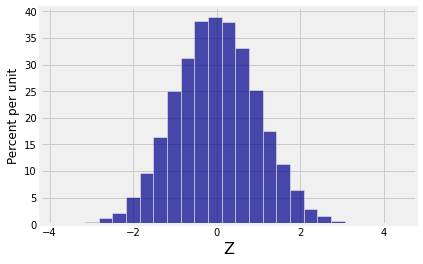

In [4]:
t1.hist('Z', bins=25)

No surprises there. Here is the empirical distribution of $1/Z$ based on the same simulated values of $Z$.

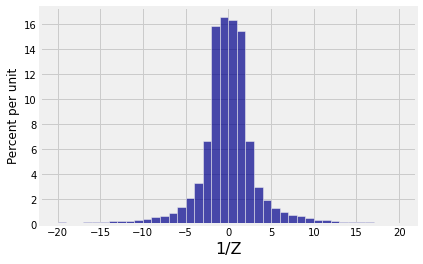

In [5]:
t1.hist('1/Z', bins = np.arange(-20, 21))

In [6]:
min(1/z), max(1/z), np.std(1/z)

(-12096.47710609047, 113218.9175662271, 852.8584541703782)

That's definitely not normal. Zooming in shows what's happening near $0$.

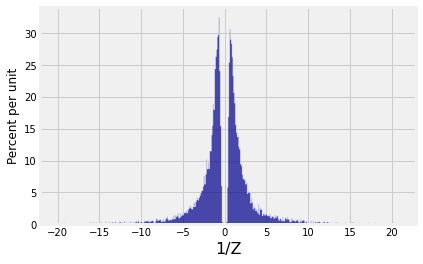

In [7]:
t1.hist('1/Z', bins = np.arange(-20, 21, 0.1))

But something interesting happens when we simulate the distribution of $\hat{\lambda} = 1/\bar{X}_n$. In the simulation, $\lambda = 0.5$ and the sample size is $n=400$.

In [8]:
lam = 0.5
n = 400
xbar = np.array([])
for i in range(reps):
    xbar = np.append(xbar, np.mean(stats.expon.rvs(size=n, scale=1/lam)))
    
t2 = Table().with_columns('Xbar', xbar,
                        '1/Xbar', 1/xbar)

The distribution of $\bar{X}_n$ is roughly normal as you expect.

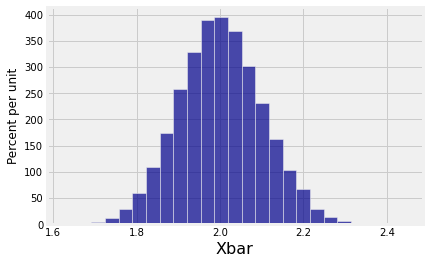

In [9]:
t2.hist('Xbar', bins=25)

The distribution of $\hat{\lambda} = 1/\bar{X_n}$ is ...

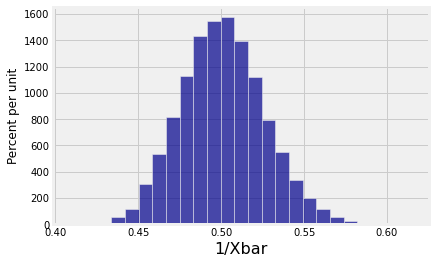

In [10]:
t2.hist('1/Xbar', bins=25)

... also approximately normal. 

That's unexpected. Let's check that the mean and SD make sense compared to the values on the horizontal axis.

In [11]:
np.mean(1/xbar), np.std(1/xbar)

(0.5009331091620624, 0.02517791316703597)

This mean and SD fit well with the normal shape of the histogram. But why is the shape normal?

## The Delta Method ##
This general method will help us understand the approximate normality of $1/\bar{X}_n$ and find the approximate mean and variance.

### Why Normal? ###

Let $g$ be a smooth non-linear function and let $Y$ be an approximately normal random variable with a small SD. In our example, $g(\theta) = 1/\theta$ and $Y = \bar{X}_n$. We have assumed that $n$ is large, so $SD(Y)$ is small.

We are interested in the distribution of $g(Y)$. Start with a familiar fact:

- A linear function of a normal variable is normal.

It's easy to believe an initial approximation:

- A linear function of an approximately normal variable is approximately normal.

If $g$ were linear, we'd be done. But $g$ isn't linear. So we need one more step.

The crucial observation is that $Y$ isn't just any normal – it's a skinny normal. Its SD is small, so almost all the probability is concentrated in a small interval three or four SDs on either side of the mean. To understand the distribution of $g(Y)$, we have to examine the behavior of $g$ on this small interval. The rest of the real line won't matter much.

We have assumed $g$ is smooth. Taylor's theorem tells us that to a first approximation, $g$ is approximately linear over any small interval. This gives us a normal approximation to the distribution of $g(Y)$, because:

- An approximately linear function of an approximately normal variable is approximately normal.

In summary, if $g$ is a smooth function and $Y$ is an approximately normal variable with a small SD, then $g(Y)$ is approximately normal.

There's a lot of hand-waving in this discussion. But the reasoning should be compelling and the simulation bears it out. For a more detailed treatment, take a graduate class.

### Which Normal? ###
To completely identify the normal approximation to the distribution of $g(Y)$, we need the mean and variance. The delta method uses a first-order Taylor expansion to identify the linear function that approximates $g$ near the point $\theta_0$.

$$
g(\theta) ~ \approx ~ g(\theta_0) + (\theta - \theta_0)g'(\theta_0)
$$

We are assuming $\theta$ is close to $\theta_0$ and, $g$ is smooth with a continuous second derivative, and $g'(\theta_0) \neq 0$.

So the Taylor expansion of $g(Y)$ around $\theta_0 = E(Y)$ is given by

$$
g(Y) ~ \approx ~ g(E(Y)) + (Y - E(Y))g'(E(Y))
$$

Take expectations on both sides:

$$
E(g(Y)) ~ \approx ~ g(E(Y)) + E(Y - E(Y))g'(E(Y)) ~ = ~ g(E(Y))
$$

because $E(Y - E(Y)) = 0$. 

Take variances on both sides of the Taylor approximation of $g(Y)$:

$$
Var(g(Y)) ~ \approx ~ Var(Y - E(Y))(g'(E(Y)))^2 ~ = ~ Var(Y)(g'(E(Y)))^2
$$


### Summary ###
Let $g$ be smooth and let $Y$ be normal with a small SD. Then the distribution of $g(Y)$ can be approximated by the normal distribution with mean $g(E(Y))$ and variance $Var(Y)(g'E(Y))^2$.

### Confidence Interval for $\lambda$ ###

We can now construct a confidence interval for the exponential rate. 

In our example, $g(\theta) = 1/\theta$ and $Y = \bar{X}_n$. The MLE of $\lambda$ is $\hat{\lambda} = g(\bar{X}_n)$.

Since $E(\bar{X_n}) = 1/\lambda$, the delta method says

$$
E(\hat{\lambda}) ~ = ~ E(g(\bar{X_n})) ~ \approx ~ g(E(\bar{X_n}) ~ = ~ \lambda
$$

In other words, $\hat{\lambda}$ is almost unbiased, as you showed more precisely in your 140 homework by calculating the mean exactly and showing that it is a slightly larger than $\lambda$.

For the variance, use $g'(\theta) = -1/\theta^2$ and $Var(\bar{X_n}) = \displaystyle{\frac{1/\lambda^2}{n}}$. By the delta method,

$$
Var(\hat{\lambda}) ~ \approx ~ Var(\bar{X_n})(g'(1/\lambda))^2 ~ = ~ \frac{1/\lambda^2}{n} \cdot \lambda^4 ~ = ~ \frac{\lambda^2}{n}
$$

For $n = 400$ and $\lambda = 0.5$, this gives $SD(\hat{\lambda}) \approx 0.025$ which agrees with our simulation.

An approximate 95% confidence interval for $\lambda$ is given by $\hat{\lambda} \pm 2\hat{\lambda}/\sqrt{n}$. 

You should identify all the approximations in that expression. For example, the SD $\lambda/\sqrt{n}$ is being approximated $\hat{\lambda}/\sqrt{n}$.

For reference, here are the empirical mean and SD based on the simulated $\hat{\lambda}$. We saw these values earlier.

In [12]:
np.mean(1/xbar), np.std(1/xbar)

(0.5009331091620624, 0.02517791316703597)

And here are the approximate expectation and SD of $\hat{\lambda}$ based on the delta method:

In [13]:
lam, ((lam**2)/n)**0.5

(0.5, 0.025)

### Accuracy of the Approximations ###

We've given good reasons for all these approximations but we haven't cranked out the detailed estimates that show that the approximations are close to the exact values of $E(\hat{\lambda})$ and $Var(\hat{\lambda})$. In this example, however, we have the good fortune of being able to check how good "$\approx$" is for the mean and variance.

By gamma sum and scaling facts, you know that $\bar{X}_n$ has the gamma $(n, n\lambda)$ distribution. In 140 homework you used this and the gamma integral to show that $E(\hat{\lambda}) = \frac{n}{n-1}\lambda$ for all $n$. For large $n$ this is pretty close to $\lambda$ which is our delta method approximation. 

An analogous calculation, starting with the expected square, gives the exact value of $Var(\hat{\lambda})$ for all $n$ as well. You should get

$$ 
Var(\hat{\lambda}) = \frac{n^2 \lambda ^2}{(n-1)^2(n-2)}
$$

For large $n$, this is almost indistinguishable from the delta method approximation $\displaystyle{\frac{\lambda^2}{n}}$.

The parameters in our simulation are $\lambda = 0.5$ and $n=400$. The cell below shows the exact $E(\hat{\lambda})$ and $SD(\hat{\lambda})$ and their delta method approximations.

In [11]:
# exact mean, approx mean, exact SD, approx SD
(n/(n-1))*lam, lam, ( (n**2)*(lam**2)/(((n-1)**2)*(n-2)) )**0.5, lam/(n**0.5)

(0.5012531328320802, 0.5, 0.02512554922892659, 0.025)

Once again, here are the mean and SD of the simulated $\hat{\lambda}$. These empirical values are close to the corresponding exact value as well as the delta method approximation.

In [12]:
np.mean(1/xbar), np.std(1/xbar)

(0.5012449517299853, 0.0250587631293048)

### Next Week ###
For large $n$, we found that in this example the distribution of the MLE $\hat{\lambda}$ is roughly normal, and we were able to see that the estimator is asympotically unbiased. We were also able to find its variance and see that it gets small as the sample size increases.

All of these calculations made heavy use of the fact that the sample is drawn from an exponential distribution. But in fact the results in the previous para have not much to do with the underlying exponential distribution; they have far more to do with the fact that $\hat{\lambda}$ is the MLE of $\lambda$. That's the topic of the next seminar.